## Project Setup and Load the Dataset

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [6]:
df = pd.read_csv("/content/drive/MyDrive/Pandas/ai4i2020.csv")

In [7]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (10000, 14)

Column names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [8]:
print("Data types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

Data types:


,0
UDI,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes

## Data Quality Checks

### Missing values and duplicates

In [9]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:


,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0



Duplicate rows:
0


### Identifier checks

In [10]:
print("Unique UDI values:", df["UDI"].nunique())
print("Unique Product ID values:", df["Product ID"].nunique())

print("\nUDI duplicates:", df["UDI"].duplicated().sum())
print("Product ID duplicates:", df["Product ID"].duplicated().sum())

Unique UDI values: 10000
Unique Product ID values: 10000

UDI duplicates: 0
Product ID duplicates: 0


### Product type distribution

In [11]:
print("Type distribution:")
display(df["Type"].value_counts())

print("\nType proportions:")
display(df["Type"].value_counts(normalize=True))

Type distribution:


,count
Type,
L,6000
M,2997
H,1003



Type proportions:


,proportion
Type,
L,0.6000
M,0.2997
H,0.1003


### Overall machine failure

In [12]:
print("Machine Failure distribution:")
display(df["Machine failure"].value_counts())

print("\nMachine Failure proportions:")
display(df["Machine failure"].value_counts(normalize=True))

Machine Failure distribution:


,count
Machine failure,
0,9661
1,339



Machine Failure proportions:


,proportion
Machine failure,
0,0.9661
1,0.0339


### Individual failure modes

In [13]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

print("Failure mode counts:")
display(df[failure_modes].sum().sort_values(ascending=False))

print("\nFailure mode proportions:")
display(df[failure_modes].mean().sort_values(ascending=False))

Failure mode counts:


,0
HDF,115
OSF,98
PWF,95
TWF,46
RNF,19



Failure mode proportions:


,0
HDF,0.0115
OSF,0.0098
PWF,0.0095
TWF,0.0046
RNF,0.0019


### Check the relationship between overall failure and failure modes

In [14]:
mode_columns = ["TWF", "HDF", "PWF", "OSF"]

mode_failure = (df[mode_columns].sum(axis=1) > 0).astype(int)

comparison = pd.crosstab(
    df["Machine failure"],
    mode_failure,
    rownames=["Machine failure"],
    colnames=["Any failure mode"]
)

display(comparison)

Any failure mode,0,1
Machine failure,,
0,9661,0
1,9,330


In [15]:
print("Failure = 0 but at least one mode = 1:",
      ((df["Machine failure"] == 0) & (mode_failure == 1)).sum())

print("Failure = 1 but no mode = 1:",
      ((df["Machine failure"] == 1) & (mode_failure == 0)).sum())

Failure = 0 but at least one mode = 1: 0
Failure = 1 but no mode = 1: 9


## Phase 3 — Exploratory Data Analysis

### Numerical summary

In [16]:
numeric_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


### Failure rate by machine Type

In [17]:
failure_by_type = (
    df.groupby("Type")["Machine failure"]
      .agg(["count", "sum", "mean"])
)

failure_by_type.columns = [
    "Machines",
    "Failures",
    "Failure Rate"
]

failure_by_type["Failure Rate"] *= 100

display(failure_by_type)

,Machines,Failures,Failure Rate
Type,,,
H,1003,21,2.093719
L,6000,235,3.916667
M,2997,83,2.769436


### Compare numerical features between failure and non-failure

In [18]:
failure_comparison = (
    df.groupby("Machine failure")[numeric_columns]
      .mean()
      .T
)

display(failure_comparison)

Machine failure,0,1
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


### Failure rate across feature ranges

In [19]:
df["Torque_Bin"] = pd.qcut(
    df["Torque [Nm]"],
    q=10,
    duplicates="drop"
)

torque_failure = (
    df.groupby("Torque_Bin", observed=True)["Machine failure"]
      .agg(["count", "sum", "mean"])
)

torque_failure.columns = [
    "Machines",
    "Failures",
    "Failure Rate"
]

torque_failure["Failure Rate"] *= 100

display(torque_failure)

,Machines,Failures,Failure Rate
Torque_Bin,,,
"(3.799, 27.2]",1002,38,3.792415
"(27.2, 31.4]",1000,9,0.900000
"(31.4, 34.8]",1004,2,0.199203
"(34.8, 37.5]",1008,7,0.694444
"(37.5, 40.1]",1013,6,0.592300
"(40.1, 42.7]",1005,6,0.597015
"(42.7, 45.3]",972,13,1.337449
"(45.3, 48.3]",1013,30,2.961500
"(48.3, 52.6]",986,44,4.462475


In [20]:
df["ToolWear_Bin"] = pd.qcut(
    df["Tool wear [min]"],
    q=10,
    duplicates="drop"
)

toolwear_failure = (
    df.groupby("ToolWear_Bin", observed=True)["Machine failure"]
      .agg(["count", "sum", "mean"])
)

toolwear_failure.columns = [
    "Machines",
    "Failures",
    "Failure Rate"
]

toolwear_failure["Failure Rate"] *= 100

display(toolwear_failure)

,Machines,Failures,Failure Rate
ToolWear_Bin,,,
"(-0.001, 20.0]",1024,27,2.636719
"(20.0, 42.0]",1003,21,2.093719
"(42.0, 64.0]",1010,18,1.782178
"(64.0, 86.0]",996,24,2.409639
"(86.0, 108.0]",995,24,2.412060
"(108.0, 130.0]",1019,23,2.257115
"(130.0, 151.3]",953,19,1.993704
"(151.3, 174.0]",1046,24,2.294455
"(174.0, 195.0]",963,31,3.219107


### Correlation with machine failure

In [21]:
correlation = df[
    numeric_columns + ["Machine failure"]
].corr()

display(
    correlation["Machine failure"]
    .sort_values(ascending=False)
)

,Machine failure
Machine failure,1.000000
Torque [Nm],0.191321
Tool wear [min],0.105448
Air temperature [K],0.082556
Process temperature [K],0.035946
Rotational speed [rpm],-0.044188


### Correlation between the predictors

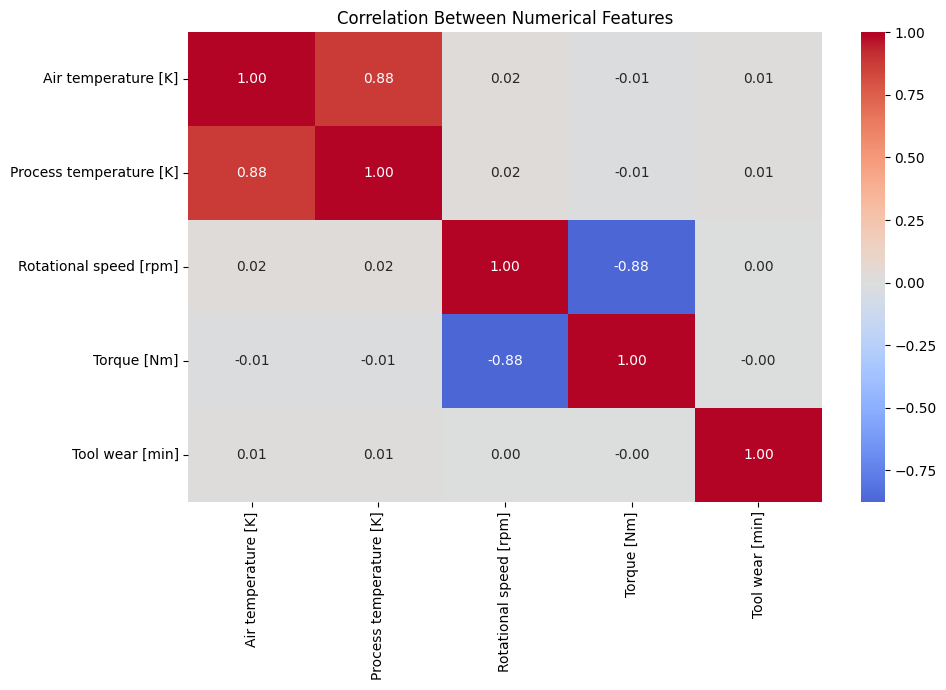

In [22]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Numerical Features")
plt.tight_layout()
plt.show()

In [23]:
corr_matrix = df[numeric_columns].corr()

display(
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    ).stack().sort_values(ascending=False)
)

Air temperature [K]      Process temperature [K]    0.876107
                         Rotational speed [rpm]     0.022670
Process temperature [K]  Rotational speed [rpm]     0.019277
Air temperature [K]      Tool wear [min]            0.013853
Process temperature [K]  Tool wear [min]            0.013488
Rotational speed [rpm]   Tool wear [min]            0.000223
Torque [Nm]              Tool wear [min]           -0.003093
Air temperature [K]      Torque [Nm]               -0.013778
Process temperature [K]  Torque [Nm]               -0.014061
Rotational speed [rpm]   Torque [Nm]               -0.875027
dtype: float64

### Clean up the EDA helper columns

In [24]:
df.drop(
    columns=["Torque_Bin", "ToolWear_Bin"],
    inplace=True
)

In [25]:
FEATURES = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temp_Diff",
    "Power_W",
    "Overstrain_Index"
]

## Phase 4 — Feature Engineering

In [26]:
df_model = df.copy()

In [27]:
df_model["Temp_Diff"] = (
    df_model["Process temperature [K]"]
    - df_model["Air temperature [K]"]
)

df_model["Power_W"] = (
    df_model["Rotational speed [rpm]"]
    * df_model["Torque [Nm]"]
)

df_model["Overstrain_Index"] = (
    df_model["Torque [Nm]"]
    * df_model["Tool wear [min]"]
)

In [28]:
engineered_features = [
    "Temp_Diff",
    "Power_W",
    "Overstrain_Index"
]

display(df_model[engineered_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
Temp_Diff,10000.0,10.00063,1.001094,7.6,9.30,9.80,11.00,12.1
Power_W,10000.0,59967.14704,10193.093881,10966.8,53105.40,59883.90,66873.75,99980.4
Overstrain_Index,10000.0,4314.66455,2826.567692,0.0,1963.65,4012.95,6279.00,16497.0


In [29]:
display(
    df_model[
        [
            "Type",
            "Air temperature [K]",
            "Process temperature [K]",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]",
            "Temp_Diff",
            "Power_W",
            "Overstrain_Index"
        ]
    ].head()
)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff,Power_W,Overstrain_Index
0,M,298.1,308.6,1551,42.8,0,10.5,66382.8,0.0
1,L,298.2,308.7,1408,46.3,3,10.5,65190.4,138.9
2,L,298.1,308.5,1498,49.4,5,10.4,74001.2,247.0
3,L,298.2,308.6,1433,39.5,7,10.4,56603.5,276.5
4,L,298.2,308.7,1408,40.0,9,10.5,56320.0,360.0


### Final Feature Definition

In [30]:
FEATURES = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temp_Diff",
    "Power_W",
    "Overstrain_Index"
]

TARGET = "Machine failure"

failure_modes = [
    "TWF",
    "HDF",
    "PWF",
    "OSF"
]

In [31]:
missing_features = [
    feature for feature in FEATURES
    if feature not in df_model.columns
]

print("Missing features:", missing_features)
print("Number of features:", len(FEATURES))
print("Features:", FEATURES)

Missing features: []
Number of features: 9
Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff', 'Power_W', 'Overstrain_Index']


### Modeling inputs and target

In [32]:
X = df_model[FEATURES].copy()
y = df_model[TARGET].copy()

In [33]:
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (10000, 9)
y shape: (10000,)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff,Power_W,Overstrain_Index
0,M,298.1,308.6,1551,42.8,0,10.5,66382.8,0.0
1,L,298.2,308.7,1408,46.3,3,10.5,65190.4,138.9
2,L,298.1,308.5,1498,49.4,5,10.4,74001.2,247.0
3,L,298.2,308.6,1433,39.5,7,10.4,56603.5,276.5
4,L,298.2,308.7,1408,40.0,9,10.5,56320.0,360.0


,Machine failure
0,0
1,0
2,0
3,0
4,0


# Phase 5 — Train/Test Split

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [35]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 9)
X_test shape: (2000, 9)
y_train shape: (8000,)
y_test shape: (2000,)


In [36]:
print("Training target distribution:")
display(y_train.value_counts())

print("\nTraining target proportions:")
display(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
display(y_test.value_counts())

print("\nTest target proportions:")
display(y_test.value_counts(normalize=True))

Training target distribution:


,count
Machine failure,
0,7729
1,271



Training target proportions:


,proportion
Machine failure,
0,0.966125
1,0.033875



Test target distribution:


,count
Machine failure,
0,1932
1,68



Test target proportions:


,proportion
Machine failure,
0,0.966
1,0.034


In [37]:
print("Feature columns identical:",
      X_train.columns.tolist() == X_test.columns.tolist())

print("\nFeature columns:")
print(X_train.columns.tolist())

Feature columns identical: True

Feature columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff', 'Power_W', 'Overstrain_Index']


# Phase 6 — Preprocessing Pipeline

### Define the feature groups

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "Type"
]

numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temp_Diff",
    "Power_W",
    "Overstrain_Index"
]

In [39]:
print("Categorical features:", categorical_features)
print("Numerical features:", numeric_features)

print("\nTotal features:",
      len(categorical_features) + len(numeric_features))

print("\nMatches FEATURES:",
      set(categorical_features + numeric_features) == set(FEATURES))

Categorical features: ['Type']
Numerical features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff', 'Power_W', 'Overstrain_Index']

Total features: 9

Matches FEATURES: True


### Create the preprocessor

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# Phase 7 — Build the Three Model Pipelines

### Imports

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### Calculate the class imbalance ratio

In [42]:
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 28.52029520295203


### Create the three pipelines

In [43]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [44]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

In [45]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    )
])

### Put the models into a dictionary

In [46]:
models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

In [47]:
print(models.keys())

dict_keys(['Logistic Regression', 'Random Forest', 'XGBoost'])


# Phase 8 — Train Model 1 Candidates

In [48]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.\n")

Training Logistic Regression...
Logistic Regression trained successfully.

Training Random Forest...
Random Forest trained successfully.

Training XGBoost...
XGBoost trained successfully.



In [49]:
for name, model in models.items():
    print(name, "→", type(model.named_steps["model"]).__name__)

Logistic Regression → LogisticRegression
Random Forest → RandomForestClassifier
XGBoost → XGBClassifier


# Phase 9 — Baseline Model Evaluation

### Import evaluation metrics

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

### Generate predictions and probabilities

In [51]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    print(f"{name} completed.")

Logistic Regression completed.
Random Forest completed.
XGBoost completed.


### Calculate the comparison table

In [52]:
metrics = []

for name, result in results.items():
    y_pred = result["y_pred"]
    y_prob = result["y_prob"]

    metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(metrics)

display(
    results_df.sort_values("F1", ascending=False)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
1,Random Forest,0.9905,0.962264,0.750000,0.842975,0.978048,0.871688
2,XGBoost,0.9855,0.753247,0.852941,0.800000,0.986436,0.891380
0,Logistic Regression,0.8585,0.179104,0.882353,0.297767,0.938505,0.429703


### Inspect the confusion matrix for each model

In [53]:
for name, result in results.items():
    print(f"\n{name}")
    print(confusion_matrix(y_test, result["y_pred"]))


Logistic Regression
[[1657  275]
 [   8   60]]

Random Forest
[[1930    2]
 [  17   51]]

XGBoost
[[1913   19]
 [  10   58]]


### Classification reports

In [54]:
for name, result in results.items():
    print(f"\n{'=' * 60}")
    print(name)
    print('=' * 60)

    print(
        classification_report(
            y_test,
            result["y_pred"],
            target_names=["No Failure", "Failure"],
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

  No Failure       1.00      0.86      0.92      1932
     Failure       0.18      0.88      0.30        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.61      2000
weighted avg       0.97      0.86      0.90      2000


Random Forest
              precision    recall  f1-score   support

  No Failure       0.99      1.00      1.00      1932
     Failure       0.96      0.75      0.84        68

    accuracy                           0.99      2000
   macro avg       0.98      0.87      0.92      2000
weighted avg       0.99      0.99      0.99      2000


XGBoost
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.75      0.85      0.80        68

    accuracy                           0.99      2000
   macro avg       0.87      0.92      0.90      2000
weighted avg       0.99      

# Phase 10 — XGBoost Probability and Threshold Analysis

In [55]:
xgb_prob = results["XGBoost"]["y_prob"]

print("Minimum probability:", xgb_prob.min())
print("Maximum probability:", xgb_prob.max())
print("Mean probability:", xgb_prob.mean())
print("Unique probabilities:", len(np.unique(xgb_prob)))

Minimum probability: 0.000119807926
Maximum probability: 0.9995548
Mean probability: 0.051317126
Unique probabilities: 2000


In [56]:
failure_probabilities = pd.DataFrame({
    "Actual": y_test.values,
    "Failure_Probability": xgb_prob
})

display(
    failure_probabilities[
        failure_probabilities["Actual"] == 1
    ].sort_values(
        "Failure_Probability",
        ascending=False
    ).head(20)
)

,Actual,Failure_Probability
1225,1,0.999555
1949,1,0.999378
64,1,0.998006
674,1,0.997885
1364,1,0.997593
969,1,0.997417
1617,1,0.996722
1598,1,0.996713
886,1,0.996685
1862,1,0.996336


In [57]:
display(
    failure_probabilities[
        failure_probabilities["Actual"] == 0
    ].sort_values(
        "Failure_Probability",
        ascending=False
    ).head(20)
)

,Actual,Failure_Probability
1203,0,0.988566
96,0,0.977789
1216,0,0.955324
1291,0,0.940942
1857,0,0.838398
1530,0,0.765115
760,0,0.729774
1722,0,0.689450
1647,0,0.665039
685,0,0.643463


In [58]:
threshold_results = []

thresholds = np.arange(0.10, 0.91, 0.05)

for threshold in thresholds:

    y_pred_threshold = (
        xgb_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),
        "False Positives": (
            (y_test == 0) &
            (y_pred_threshold == 1)
        ).sum(),
        "False Negatives": (
            (y_test == 1) &
            (y_pred_threshold == 0)
        ).sum()
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,Threshold,Precision,Recall,F1,Accuracy,False Positives,False Negatives
0,0.10,0.368421,0.926471,0.527197,0.9435,108,5
1,0.15,0.476923,0.911765,0.626263,0.9630,68,6
2,0.20,0.525424,0.911765,0.666667,0.9690,56,6
3,0.25,0.558559,0.911765,0.692737,0.9725,49,6
4,0.30,0.592233,0.897059,0.713450,0.9755,42,7
5,0.35,0.618557,0.882353,0.727273,0.9775,37,8
6,0.40,0.678161,0.867647,0.761290,0.9815,28,9
7,0.45,0.716049,0.852941,0.778523,0.9835,23,10
8,0.50,0.753247,0.852941,0.800000,0.9855,19,10
9,0.55,0.794521,0.852941,0.822695,0.9875,15,10


# Phase 11 — Final Model 1 Evaluation

In [59]:
FINAL_THRESHOLD = 0.80

xgb_final_pred = (
    xgb_prob >= FINAL_THRESHOLD
).astype(int)

In [60]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, xgb_final_pred),
    "Precision": precision_score(
        y_test,
        xgb_final_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        xgb_final_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        xgb_final_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        xgb_prob
    ),
    "PR-AUC": average_precision_score(
        y_test,
        xgb_prob
    )
}

display(
    pd.DataFrame(
        final_metrics.items(),
        columns=["Metric", "Value"]
    )
)

,Metric,Value
0,Accuracy,0.991500
1,Precision,0.918033
2,Recall,0.823529
3,F1,0.868217
4,ROC-AUC,0.986436
5,PR-AUC,0.891380


In [61]:
final_cm = confusion_matrix(
    y_test,
    xgb_final_pred
)

print(final_cm)

[[1927    5]
 [  12   56]]


In [62]:
print(
    classification_report(
        y_test,
        xgb_final_pred,
        target_names=["No Failure", "Failure"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  No Failure       0.99      1.00      1.00      1932
     Failure       0.92      0.82      0.87        68

    accuracy                           0.99      2000
   macro avg       0.96      0.91      0.93      2000
weighted avg       0.99      0.99      0.99      2000



# Phase 12 — Model 2: Failure Mode Classification

### Build the failure-mode dataset

In [63]:
df_mode = df_model[FEATURES + failure_modes].copy()

In [64]:
print("Failure-mode dataset shape:", df_mode.shape)

display(df_mode.head())

Failure-mode dataset shape: (10000, 13)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff,Power_W,Overstrain_Index,TWF,HDF,PWF,OSF
0,M,298.1,308.6,1551,42.8,0,10.5,66382.8,0.0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,10.5,65190.4,138.9,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,10.4,74001.2,247.0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,10.4,56603.5,276.5,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,10.5,56320.0,360.0,0,0,0,0


In [65]:
mode_mask = df_mode[failure_modes].sum(axis=1) > 0

print("Rows with at least one failure mode:", mode_mask.sum())
print("Rows with no failure mode:", (~mode_mask).sum())

Rows with at least one failure mode: 330
Rows with no failure mode: 9670


In [66]:
display(
    df_mode.loc[mode_mask, failure_modes].sum()
)

,0
TWF,46
HDF,115
PWF,95
OSF,98


# Phase 13 — Analyze the Multi-Label Structure

In [67]:
df_mode = df_mode.loc[mode_mask].copy()

print("Model 2 dataset shape:", df_mode.shape)

Model 2 dataset shape: (330, 13)


In [68]:
df_mode["num_modes"] = df_mode[failure_modes].sum(axis=1)

print("Number of failure modes per observation:")
display(
    df_mode["num_modes"].value_counts().sort_index()
)

Number of failure modes per observation:


,count
num_modes,
1,307
2,22
3,1


In [69]:
def get_mode_names(row):
    return [
        mode
        for mode in failure_modes
        if row[mode] == 1
    ]

df_mode["mode_combination"] = df_mode.apply(
    get_mode_names,
    axis=1
)

display(
    df_mode["mode_combination"]
    .apply(lambda x: " + ".join(x))
    .value_counts()
)

,count
mode_combination,
HDF,106
PWF,80
OSF,78
TWF,43
PWF + OSF,11
HDF + OSF,6
HDF + PWF,3
TWF + OSF,2
TWF + PWF + OSF,1


In [70]:
display(
    df_mode[failure_modes].head(20)
)

,TWF,HDF,PWF,OSF
50,0,0,1,0
69,0,0,1,1
77,1,0,0,0
160,0,0,0,1
161,0,0,0,1
168,0,0,1,0
194,0,0,1,0
207,0,0,1,0
242,0,0,0,1
248,0,0,0,1


In [71]:
df_mode.drop(
    columns=["num_modes", "mode_combination"],
    inplace=True
)

# Phase 14 — Prepare Model 2 Inputs and Targets

In [72]:
X_mode = df_mode[FEATURES].copy()
y_mode = df_mode[failure_modes].copy()

In [73]:
print("X_mode shape:", X_mode.shape)
print("y_mode shape:", y_mode.shape)

print("\nX_mode columns:")
print(X_mode.columns.tolist())

print("\ny_mode columns:")
print(y_mode.columns.tolist())

X_mode shape: (330, 9)
y_mode shape: (330, 4)

X_mode columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff', 'Power_W', 'Overstrain_Index']

y_mode columns:
['TWF', 'HDF', 'PWF', 'OSF']


In [74]:
print("\nPositive labels:")
display(y_mode.sum())


Positive labels:


,0
TWF,46
HDF,115
PWF,95
OSF,98


# Phase 15 — Multi-Label Train / Validation / Test Split

In [75]:
!pip install iterative-stratification -q

In [76]:
import importlib.util

print(
    "iterative-stratification installed:",
    importlib.util.find_spec("iterstrat") is not None
)

iterative-stratification installed: True


### Create the first split

In [77]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

msss_1 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    msss_1.split(X_mode, y_mode)
)

X_mode_train = X_mode.iloc[train_idx].copy()
y_mode_train = y_mode.iloc[train_idx].copy()

X_mode_temp = X_mode.iloc[temp_idx].copy()
y_mode_temp = y_mode.iloc[temp_idx].copy()

print("Training shape:", X_mode_train.shape)
print("Temporary shape:", X_mode_temp.shape)

Training shape: (235, 9)
Temporary shape: (95, 9)


### Split the remaining 30% into validation and test

In [78]:
msss_2 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    msss_2.split(X_mode_temp, y_mode_temp)
)

X_mode_val = X_mode_temp.iloc[val_idx].copy()
y_mode_val = y_mode_temp.iloc[val_idx].copy()

X_mode_test = X_mode_temp.iloc[test_idx].copy()
y_mode_test = y_mode_temp.iloc[test_idx].copy()

print("Validation shape:", X_mode_val.shape)
print("Test shape:", X_mode_test.shape)

Validation shape: (44, 9)
Test shape: (51, 9)


### Verify the label distribution

In [79]:
split_distributions = pd.DataFrame({
    "Train": y_mode_train.mean(),
    "Validation": y_mode_val.mean(),
    "Test": y_mode_test.mean()
}) * 100

display(split_distributions)

,Train,Validation,Test
TWF,13.617021,15.909091,13.725490
HDF,34.042553,38.636364,35.294118
PWF,28.510638,31.818182,27.450980
OSF,29.361702,31.818182,29.411765


In [80]:
split_counts = pd.DataFrame({
    "Train": y_mode_train.sum(),
    "Validation": y_mode_val.sum(),
    "Test": y_mode_test.sum()
})

display(split_counts)

,Train,Validation,Test
TWF,32,7,7
HDF,80,17,18
PWF,67,14,14
OSF,69,14,15


In [81]:
print("Total observations:",
      len(X_mode_train) +
      len(X_mode_val) +
      len(X_mode_test))

print("Original observations:", len(X_mode))

Total observations: 330
Original observations: 330


# Phase 16 — Model 2 Preprocessing

### Create the Model 2 preprocessor

In [82]:
preprocessor_mode = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

### Verify the feature groups

In [83]:
print("Categorical features:", categorical_features)
print("Numerical features:", numeric_features)

print("\nTotal features:",
      len(categorical_features) + len(numeric_features))

print("\nMatches FEATURES:",
      set(categorical_features + numeric_features) == set(FEATURES))

Categorical features: ['Type']
Numerical features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff', 'Power_W', 'Overstrain_Index']

Total features: 9

Matches FEATURES: True


# Phase 17 — Choose the Multi-Label Model

### Import MultiOutputClassifier

In [84]:
from sklearn.multioutput import MultiOutputClassifier

### Calculate per-label imbalance

In [85]:
mode_class_weights = {}

for mode in failure_modes:
    positives = y_mode_train[mode].sum()
    negatives = len(y_mode_train) - positives

    mode_class_weights[mode] = negatives / positives

print("Mode class ratios:")
for mode, weight in mode_class_weights.items():
    print(f"{mode}: {weight:.3f}")

Mode class ratios:
TWF: 6.344
HDF: 1.938
PWF: 2.507
OSF: 2.406


### Create the Model 2 pipeline

In [86]:
mode_model = Pipeline([
    (
        "preprocessor",
        preprocessor_mode
    ),
    (
        "model",
        MultiOutputClassifier(
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    )
])

In [87]:
print(mode_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]',
                                                   'Temp_Diff', 'Power_W',
                                                   'Overstrain_Index']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('model',
                 MultiOutputClassifier(estimator=XGBClassifier(base_sco...
                                                               feat

# Phase 18 — Train Model 2

In [88]:
mode_model.fit(
    X_mode_train,
    y_mode_train
)

print("Model 2 trained successfully.")

Model 2 trained successfully.


In [89]:
for i, mode in enumerate(failure_modes):
    estimator = mode_model.named_steps["model"].estimators_[i]
    print(f"{mode} → {type(estimator).__name__}")

TWF → XGBClassifier
HDF → XGBClassifier
PWF → XGBClassifier
OSF → XGBClassifier


# Phase 19 — Validation Predictions

In [90]:
mode_val_prob = mode_model.predict_proba(X_mode_val)

print("Number of outputs:", len(mode_val_prob))

for i, mode in enumerate(failure_modes):
    print(
        f"{mode}: "
        f"probability shape = {mode_val_prob[i].shape}"
    )

Number of outputs: 4
TWF: probability shape = (44, 2)
HDF: probability shape = (44, 2)
PWF: probability shape = (44, 2)
OSF: probability shape = (44, 2)


In [91]:
mode_val_prob_positive = np.column_stack([
    mode_val_prob[i][:, 1]
    for i in range(len(failure_modes))
])

mode_val_prob_positive_df = pd.DataFrame(
    mode_val_prob_positive,
    columns=failure_modes,
    index=X_mode_val.index
)

display(mode_val_prob_positive_df.head())

,TWF,HDF,PWF,OSF
380,0.008093,0.002429,0.986023,0.002860
442,0.005547,0.001255,0.989305,0.005776
1095,0.008468,0.002463,0.986023,0.003074
1324,0.052132,0.004137,0.953047,0.954312
1682,0.995308,0.002281,0.009590,0.003879


In [92]:
mode_val_pred_default = (
    mode_val_prob_positive_df >= 0.50
).astype(int)

for mode in failure_modes:
    print(f"\n{'=' * 50}")
    print(mode)
    print('=' * 50)

    print(
        classification_report(
            y_mode_val[mode],
            mode_val_pred_default[mode],
            target_names=["No " + mode, mode],
            zero_division=0
        )
    )


TWF
              precision    recall  f1-score   support

      No TWF       0.97      1.00      0.99        37
         TWF       1.00      0.86      0.92         7

    accuracy                           0.98        44
   macro avg       0.99      0.93      0.95        44
weighted avg       0.98      0.98      0.98        44


HDF
              precision    recall  f1-score   support

      No HDF       1.00      1.00      1.00        27
         HDF       1.00      1.00      1.00        17

    accuracy                           1.00        44
   macro avg       1.00      1.00      1.00        44
weighted avg       1.00      1.00      1.00        44


PWF
              precision    recall  f1-score   support

      No PWF       1.00      1.00      1.00        30
         PWF       1.00      1.00      1.00        14

    accuracy                           1.00        44
   macro avg       1.00      1.00      1.00        44
weighted avg       1.00      1.00      1.00        44


OSF

In [93]:
for mode in failure_modes:
    print(f"\n{mode}")
    print(
        confusion_matrix(
            y_mode_val[mode],
            mode_val_pred_default[mode]
        )
    )


TWF
[[37  0]
 [ 1  6]]

HDF
[[27  0]
 [ 0 17]]

PWF
[[30  0]
 [ 0 14]]

OSF
[[30  0]
 [ 0 14]]


In [94]:
from sklearn.metrics import hamming_loss

print(
    "Validation Hamming Loss:",
    hamming_loss(
        y_mode_val,
        mode_val_pred_default
    )
)

print(
    "Validation Micro F1:",
    f1_score(
        y_mode_val,
        mode_val_pred_default,
        average="micro",
        zero_division=0
    )
)

print(
    "Validation Macro F1:",
    f1_score(
        y_mode_val,
        mode_val_pred_default,
        average="macro",
        zero_division=0
    )
)

Validation Hamming Loss: 0.005681818181818182
Validation Micro F1: 0.9902912621359223
Validation Macro F1: 0.9807692307692308


# Phase 20 — Per-Mode Threshold Analysis

In [95]:
mode_threshold_results = {}

thresholds = np.arange(0.20, 0.81, 0.10)

for mode in failure_modes:

    y_true = y_mode_val[mode]
    probabilities = mode_val_prob_positive_df[mode]

    mode_results = []

    for threshold in thresholds:

        y_pred = (
            probabilities >= threshold
        ).astype(int)

        mode_results.append({
            "Threshold": threshold,
            "Precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "Recall": recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "F1": f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "False Positives": (
                (y_true == 0) &
                (y_pred == 1)
            ).sum(),
            "False Negatives": (
                (y_true == 1) &
                (y_pred == 0)
            ).sum()
        })

    mode_threshold_results[mode] = pd.DataFrame(
        mode_results
    )

In [96]:
for mode in failure_modes:

    print(f"\n{'=' * 60}")
    print(f"{mode} THRESHOLD ANALYSIS")
    print('=' * 60)

    display(
        mode_threshold_results[mode]
    )


TWF THRESHOLD ANALYSIS


,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.2,0.857143,0.857143,0.857143,1,1
1,0.3,0.857143,0.857143,0.857143,1,1
2,0.4,1.000000,0.857143,0.923077,0,1
3,0.5,1.000000,0.857143,0.923077,0,1
4,0.6,1.000000,0.857143,0.923077,0,1
5,0.7,1.000000,0.857143,0.923077,0,1
6,0.8,1.000000,0.714286,0.833333,0,2



HDF THRESHOLD ANALYSIS


,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.2,1.0,1.000000,1.000000,0,0
1,0.3,1.0,1.000000,1.000000,0,0
2,0.4,1.0,1.000000,1.000000,0,0
3,0.5,1.0,1.000000,1.000000,0,0
4,0.6,1.0,1.000000,1.000000,0,0
5,0.7,1.0,0.941176,0.969697,0,1
6,0.8,1.0,0.941176,0.969697,0,1



PWF THRESHOLD ANALYSIS


,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.2,1.0,1.0,1.0,0,0
1,0.3,1.0,1.0,1.0,0,0
2,0.4,1.0,1.0,1.0,0,0
3,0.5,1.0,1.0,1.0,0,0
4,0.6,1.0,1.0,1.0,0,0
5,0.7,1.0,1.0,1.0,0,0
6,0.8,1.0,1.0,1.0,0,0



OSF THRESHOLD ANALYSIS


,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.2,1.0,1.000000,1.000000,0,0
1,0.3,1.0,1.000000,1.000000,0,0
2,0.4,1.0,1.000000,1.000000,0,0
3,0.5,1.0,1.000000,1.000000,0,0
4,0.6,1.0,1.000000,1.000000,0,0
5,0.7,1.0,1.000000,1.000000,0,0
6,0.8,1.0,0.928571,0.962963,0,1


In [97]:
MODE_THRESHOLDS = {
    "TWF": 0.50,
    "HDF": 0.50,
    "PWF": 0.50,
    "OSF": 0.50
}

print(MODE_THRESHOLDS)

{'TWF': 0.5, 'HDF': 0.5, 'PWF': 0.5, 'OSF': 0.5}


# Phase 21 — Final Model 2 Test Evaluation

In [98]:
mode_test_prob = mode_model.predict_proba(X_mode_test)

mode_test_prob_positive = np.column_stack([
    mode_test_prob[i][:, 1]
    for i in range(len(failure_modes))
])

mode_test_prob_positive_df = pd.DataFrame(
    mode_test_prob_positive,
    columns=failure_modes,
    index=X_mode_test.index
)

display(mode_test_prob_positive_df.head())

,TWF,HDF,PWF,OSF
69,0.006175,0.000598,0.973429,0.991677
161,0.020449,0.001034,0.006593,0.992224
259,0.007471,0.001821,0.995308,0.002714
880,0.007288,0.011859,0.984640,0.002678
1123,0.030510,0.001855,0.986277,0.002607


In [99]:
mode_test_pred = pd.DataFrame(
    0,
    index=X_mode_test.index,
    columns=failure_modes
)

for mode in failure_modes:
    mode_test_pred[mode] = (
        mode_test_prob_positive_df[mode]
        >= MODE_THRESHOLDS[mode]
    ).astype(int)

display(mode_test_pred.head())

,TWF,HDF,PWF,OSF
69,0,0,1,1
161,0,0,0,1
259,0,0,1,0
880,0,0,1,0
1123,0,0,1,0


In [100]:
for mode in failure_modes:
    print(f"\n{'=' * 60}")
    print(f"{mode} — TEST RESULTS")
    print('=' * 60)

    print(
        classification_report(
            y_mode_test[mode],
            mode_test_pred[mode],
            target_names=["No " + mode, mode],
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(
        confusion_matrix(
            y_mode_test[mode],
            mode_test_pred[mode]
        )
    )


TWF — TEST RESULTS
              precision    recall  f1-score   support

      No TWF       1.00      1.00      1.00        44
         TWF       1.00      1.00      1.00         7

    accuracy                           1.00        51
   macro avg       1.00      1.00      1.00        51
weighted avg       1.00      1.00      1.00        51

Confusion Matrix:
[[44  0]
 [ 0  7]]

HDF — TEST RESULTS
              precision    recall  f1-score   support

      No HDF       1.00      1.00      1.00        33
         HDF       1.00      1.00      1.00        18

    accuracy                           1.00        51
   macro avg       1.00      1.00      1.00        51
weighted avg       1.00      1.00      1.00        51

Confusion Matrix:
[[33  0]
 [ 0 18]]

PWF — TEST RESULTS
              precision    recall  f1-score   support

      No PWF       1.00      1.00      1.00        37
         PWF       1.00      1.00      1.00        14

    accuracy                           1.00     

In [101]:
test_hamming_loss = hamming_loss(
    y_mode_test,
    mode_test_pred
)

test_micro_f1 = f1_score(
    y_mode_test,
    mode_test_pred,
    average="micro",
    zero_division=0
)

test_macro_f1 = f1_score(
    y_mode_test,
    mode_test_pred,
    average="macro",
    zero_division=0
)

print("Test Hamming Loss:", test_hamming_loss)
print("Test Micro F1:", test_micro_f1)
print("Test Macro F1:", test_macro_f1)

Test Hamming Loss: 0.004901960784313725
Test Micro F1: 0.9906542056074766
Test Macro F1: 0.9913793103448276


# Explainability and Anomaly Detection

## SHAP Explainability

### Extract the fitted preprocessing and XGBoost model

In [102]:
final_preprocessor = xgb_pipeline.named_steps["preprocessor"]
final_xgb = xgb_pipeline.named_steps["model"]

print(type(final_preprocessor).__name__)
print(type(final_xgb).__name__)

ColumnTransformer
XGBClassifier


### Transform the test data

In [103]:
X_test_transformed = final_preprocessor.transform(X_test)

print("Transformed X_test shape:", X_test_transformed.shape)

Transformed X_test shape: (2000, 11)


### Get the transformed feature names

In [104]:
feature_names_transformed = (
    final_preprocessor
    .get_feature_names_out()
)

print("Number of transformed features:", len(feature_names_transformed))
print("\nTransformed feature names:")
print(feature_names_transformed)

Number of transformed features: 11

Transformed feature names:
['num__Air temperature [K]' 'num__Process temperature [K]'
 'num__Rotational speed [rpm]' 'num__Torque [Nm]' 'num__Tool wear [min]'
 'num__Temp_Diff' 'num__Power_W' 'num__Overstrain_Index' 'cat__Type_H'
 'cat__Type_L' 'cat__Type_M']


### Create the SHAP explainer

In [105]:
import shap

explainer = shap.TreeExplainer(final_xgb)

shap_values = explainer.shap_values(
    X_test_transformed
)

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (2000, 11)


### Global feature importance

In [106]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names_transformed,
    "Mean |SHAP|": mean_abs_shap
}).sort_values(
    "Mean |SHAP|",
    ascending=False
)

display(shap_importance)

,Feature,Mean |SHAP|
4,num__Tool wear [min],1.432270
2,num__Rotational speed [rpm],1.285733
6,num__Power_W,1.193858
3,num__Torque [Nm],0.911298
7,num__Overstrain_Index,0.752118
5,num__Temp_Diff,0.662636
1,num__Process temperature [K],0.388504
0,num__Air temperature [K],0.383689
10,cat__Type_M,0.064403
9,cat__Type_L,0.049293


### SHAP summary plot

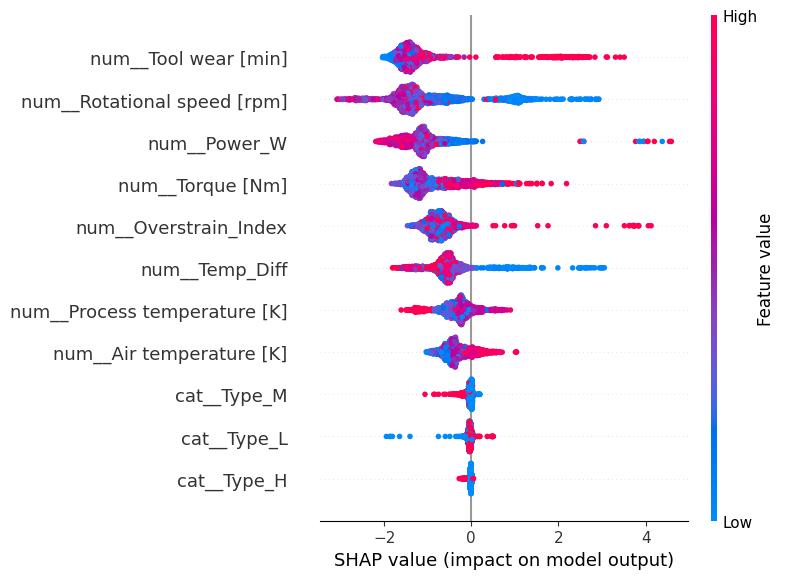

In [107]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names_transformed
)

### Explain one individual prediction

In [108]:
highest_risk_position = np.argmax(xgb_prob)

highest_risk_index = X_test.index[highest_risk_position]

print("Original dataframe index:", highest_risk_index)
print("Predicted failure probability:", xgb_prob[highest_risk_position])
print("Actual failure:", y_test.loc[highest_risk_index])

Original dataframe index: 6497
Predicted failure probability: 0.9995548
Actual failure: 1


In [109]:
display(
    X_test.loc[[highest_risk_index]]
)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff,Power_W,Overstrain_Index
6497,L,300.8,309.9,1312,65.3,192,9.1,85673.6,12537.6


In [110]:
individual_shap = shap_values[highest_risk_position]

individual_explanation = pd.DataFrame({
    "Feature": feature_names_transformed,
    "SHAP Value": individual_shap
}).sort_values(
    "SHAP Value",
    ascending=False
)

display(individual_explanation)

,Feature,SHAP Value
7,num__Overstrain_Index,2.849638
6,num__Power_W,2.493596
3,num__Torque [Nm],1.506955
2,num__Rotational speed [rpm],0.990686
1,num__Process temperature [K],0.053679
9,cat__Type_L,0.049974
10,cat__Type_M,0.046525
8,cat__Type_H,0.006185
0,num__Air temperature [K],-0.240815
4,num__Tool wear [min],-0.344399


### Create a visual explanation for that machine

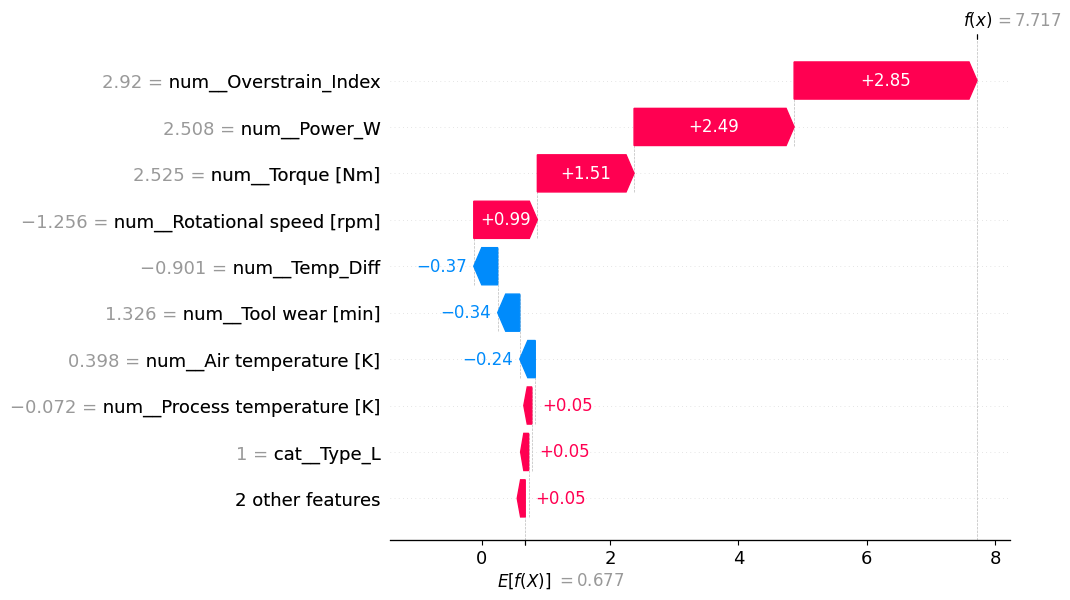

In [111]:
shap.waterfall_plot(
    shap.Explanation(
        values=individual_shap,
        base_values=explainer.expected_value,
        data=X_test_transformed[highest_risk_position],
        feature_names=feature_names_transformed
    )
)

# Model 2 Explainability

In [112]:
mode_estimators = mode_model.named_steps["model"].estimators_

for i, mode in enumerate(failure_modes):
    print(
        mode,
        "→",
        type(mode_estimators[i]).__name__
    )

TWF → XGBClassifier
HDF → XGBClassifier
PWF → XGBClassifier
OSF → XGBClassifier


In [113]:
mode_preprocessor = mode_model.named_steps["preprocessor"]

X_mode_test_transformed = (
    mode_preprocessor.transform(X_mode_test)
)

mode_feature_names = (
    mode_preprocessor.get_feature_names_out()
)

print("Transformed test shape:",
      X_mode_test_transformed.shape)

print("Number of transformed features:",
      len(mode_feature_names))

print(mode_feature_names)

Transformed test shape: (51, 11)
Number of transformed features: 11
['num__Air temperature [K]' 'num__Process temperature [K]'
 'num__Rotational speed [rpm]' 'num__Torque [Nm]' 'num__Tool wear [min]'
 'num__Temp_Diff' 'num__Power_W' 'num__Overstrain_Index' 'cat__Type_H'
 'cat__Type_L' 'cat__Type_M']


In [114]:
mode_shap_importance = {}

for i, mode in enumerate(failure_modes):

    estimator = mode_estimators[i]

    mode_explainer = shap.TreeExplainer(
        estimator
    )

    mode_shap_values = mode_explainer.shap_values(
        X_mode_test_transformed
    )

    mean_abs_shap = np.abs(
        mode_shap_values
    ).mean(axis=0)

    mode_shap_importance[mode] = (
        pd.DataFrame({
            "Feature": mode_feature_names,
            "Mean |SHAP|": mean_abs_shap
        })
        .sort_values(
            "Mean |SHAP|",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [115]:
for mode in failure_modes:

    print(f"\n{'=' * 60}")
    print(f"{mode} — GLOBAL SHAP IMPORTANCE")
    print('=' * 60)

    display(
        mode_shap_importance[mode]
    )


TWF — GLOBAL SHAP IMPORTANCE


,Feature,Mean |SHAP|
0,num__Tool wear [min],1.468276
1,num__Torque [Nm],1.297624
2,num__Rotational speed [rpm],1.052731
3,cat__Type_L,0.628827
4,num__Overstrain_Index,0.606593
5,num__Power_W,0.476970
6,num__Temp_Diff,0.462545
7,num__Air temperature [K],0.324515
8,num__Process temperature [K],0.135536
9,cat__Type_M,0.094056



HDF — GLOBAL SHAP IMPORTANCE


,Feature,Mean |SHAP|
0,num__Temp_Diff,3.073187
1,num__Rotational speed [rpm],1.395196
2,num__Air temperature [K],0.636122
3,num__Overstrain_Index,0.437472
4,num__Tool wear [min],0.397638
5,num__Torque [Nm],0.269714
6,num__Power_W,0.150078
7,cat__Type_L,0.146734
8,num__Process temperature [K],0.036758
9,cat__Type_M,0.002313



PWF — GLOBAL SHAP IMPORTANCE


,Feature,Mean |SHAP|
0,num__Power_W,2.524275
1,num__Torque [Nm],1.029843
2,num__Rotational speed [rpm],0.534778
3,num__Tool wear [min],0.487294
4,num__Temp_Diff,0.291367
5,num__Overstrain_Index,0.240689
6,num__Air temperature [K],0.011811
7,num__Process temperature [K],0.006138
8,cat__Type_M,0.003847
9,cat__Type_H,0.000000



OSF — GLOBAL SHAP IMPORTANCE


,Feature,Mean |SHAP|
0,num__Overstrain_Index,3.099383
1,num__Tool wear [min],1.189672
2,num__Power_W,0.565535
3,cat__Type_L,0.485045
4,num__Temp_Diff,0.403432
5,num__Torque [Nm],0.200692
6,num__Process temperature [K],0.054226
7,num__Air temperature [K],0.016307
8,num__Rotational speed [rpm],0.006914
9,cat__Type_H,0.000000


# Anomaly Detection

### Prepare the anomaly-detection data

In [116]:
X_anomaly = df_model[numeric_features].copy()

normal_mask = df_model["Machine failure"] == 0

X_anomaly_normal = X_anomaly.loc[normal_mask].copy()

print("All observations:", X_anomaly.shape)
print("Normal observations:", X_anomaly_normal.shape)

All observations: (10000, 8)
Normal observations: (9661, 8)


## Isolation Forest

In [117]:
from sklearn.ensemble import IsolationForest
isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

In [118]:
isolation_forest.fit(X_anomaly_normal)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


In [119]:
anomaly_scores = isolation_forest.decision_function(
    X_anomaly
)

anomaly_predictions = isolation_forest.predict(
    X_anomaly
)

In [120]:
anomaly_results = pd.DataFrame({
    "Anomaly_Score": anomaly_scores,
    "Anomaly_Label": anomaly_predictions,
    "Machine_Failure": df_model["Machine failure"].values
})

display(anomaly_results.head())

,Anomaly_Score,Anomaly_Label,Machine_Failure
0,0.125660,1,0
1,0.142940,1,0
2,0.112206,1,0
3,0.149202,1,0
4,0.152514,1,0


In [121]:
print("Minimum anomaly score:", anomaly_scores.min())
print("Maximum anomaly score:", anomaly_scores.max())
print("Mean anomaly score:", anomaly_scores.mean())

Minimum anomaly score: -0.08092248756294218
Maximum anomaly score: 0.2070216729676861
Mean anomaly score: 0.13311666002254932


### Examine how many observations were flagged

In [122]:
print(
    "Total anomalies:",
    (anomaly_predictions == -1).sum()
)

print(
    "Total normal:",
    (anomaly_predictions == 1).sum()
)

Total anomalies: 170
Total normal: 9830


In [123]:
anomaly_by_failure = (
    anomaly_results
    .groupby("Machine_Failure")["Anomaly_Label"]
    .apply(lambda x: (x == -1).mean() * 100)
)

display(anomaly_by_failure)

,Anomaly_Label
Machine_Failure,
0,1.004037
1,21.533923


### Inspect the most anomalous machines

In [124]:
most_anomalous = (
    anomaly_results
    .sort_values("Anomaly_Score")
    .head(20)
)

display(most_anomalous)

,Anomaly_Score,Anomaly_Label,Machine_Failure
847,-0.080922,-1,1
5152,-0.077006,-1,0
4988,-0.075498,-1,1
903,-0.065164,-1,1
1095,-0.064150,-1,1
4997,-0.062191,-1,1
8114,-0.061848,-1,0
4383,-0.059194,-1,1
4762,-0.058483,-1,1
3867,-0.057270,-1,1


In [125]:
most_anomalous_indices = most_anomalous.index

display(
    df_model.loc[
        most_anomalous_indices,
        FEATURES + ["Machine failure", "TWF", "HDF", "PWF", "OSF"]
    ]
)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff,Power_W,Overstrain_Index,Machine failure,TWF,HDF,PWF,OSF
847,L,296.4,307.4,2833,5.6,213,11.0,15864.8,1192.8,1,0,0,1,0
5152,L,304.3,313.5,2643,12.7,21,9.2,33566.1,266.7,0,0,0,0,0
4988,L,303.8,313.1,2497,13.0,5,9.3,32461.0,65.0,1,0,0,1,0
903,L,295.7,306.2,2270,14.6,149,10.5,33142.0,2175.4,1,0,0,1,0
1095,L,296.9,307.5,2721,9.3,18,10.6,25305.3,167.4,1,0,0,1,0
4997,M,303.6,312.8,2659,11.4,26,9.2,30312.6,296.4,1,0,0,1,0
8114,H,300.4,311.8,2496,13.5,5,11.4,33696.0,67.5,0,0,0,0,0
4383,L,301.7,309.5,1298,65.5,229,7.8,85019.0,14999.5,1,0,1,0,1
4762,M,303.7,312.0,2663,11.4,71,8.3,30358.2,809.4,1,0,0,1,0
3867,M,302.7,311.6,2709,9.7,2,8.9,26277.3,19.4,1,0,0,1,0


# Save the final models

### Create an artifacts directory

In [126]:
from pathlib import Path

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print("Artifact directory:", ARTIFACT_DIR.resolve())

Artifact directory: /content/artifacts


In [127]:
import joblib

In [128]:
model1_path = ARTIFACT_DIR / "model1_failure_xgboost.joblib"

joblib.dump(
    xgb_pipeline,
    model1_path
)

print("Saved:", model1_path)

Saved: artifacts/model1_failure_xgboost.joblib


In [129]:
model2_path = ARTIFACT_DIR / "model2_failure_modes_xgboost.joblib"

joblib.dump(
    mode_model,
    model2_path
)

print("Saved:", model2_path)

Saved: artifacts/model2_failure_modes_xgboost.joblib


In [130]:
anomaly_path = ARTIFACT_DIR / "anomaly_isolation_forest.joblib"

joblib.dump(
    isolation_forest,
    anomaly_path
)

print("Saved:", anomaly_path)

Saved: artifacts/anomaly_isolation_forest.joblib


### Save the project configuration

In [131]:
project_config = {
    "features": FEATURES,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,

    "machine_failure": {
        "model": "XGBoost",
        "threshold": FINAL_THRESHOLD
    },

    "failure_modes": {
        "model": "MultiOutput XGBoost",
        "thresholds": MODE_THRESHOLDS
    },

    "anomaly_detection": {
        "model": "IsolationForest",
        "numeric_features": numeric_features,
        "contamination": 0.01
    }
}

In [132]:
config_path = ARTIFACT_DIR / "project_config.joblib"

joblib.dump(
    project_config,
    config_path
)

print("Saved:", config_path)

Saved: artifacts/project_config.joblib


In [133]:
print("\nSaved artifacts:")

for path in ARTIFACT_DIR.iterdir():
    print(
        f"{path.name} "
        f"({path.stat().st_size / 1024:.1f} KB)"
    )


Saved artifacts:
project_config.joblib (0.6 KB)
anomaly_isolation_forest.joblib (4021.9 KB)
model2_failure_modes_xgboost.joblib (986.6 KB)
model1_failure_xgboost.joblib (459.4 KB)


## Reload Test

In [134]:
loaded_model1 = joblib.load(
    model1_path
)

loaded_model2 = joblib.load(
    model2_path
)

loaded_anomaly = joblib.load(
    anomaly_path
)

loaded_config = joblib.load(
    config_path
)

print("All artifacts loaded successfully.")

All artifacts loaded successfully.


In [135]:
print("Features:")
print(loaded_config["features"])

print("\nModel 1 threshold:")
print(loaded_config["machine_failure"]["threshold"])

print("\nModel 2 thresholds:")
print(loaded_config["failure_modes"]["thresholds"])

Features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff', 'Power_W', 'Overstrain_Index']

Model 1 threshold:
0.8

Model 2 thresholds:
{'TWF': 0.5, 'HDF': 0.5, 'PWF': 0.5, 'OSF': 0.5}


### Verify Model 1 produces the same prediction

In [136]:
sample_X = X_test.iloc[[0]]

original_probability = xgb_pipeline.predict_proba(
    sample_X
)[:, 1][0]

loaded_probability = loaded_model1.predict_proba(
    sample_X
)[:, 1][0]

print("Original probability:", original_probability)
print("Loaded probability:  ", loaded_probability)

print(
    "Prediction identical:",
    np.isclose(
        original_probability,
        loaded_probability
    )
)

Original probability: 0.116953894
Loaded probability:   0.116953894
Prediction identical: True


### Verify Model 2

In [137]:
sample_mode_X = X_mode_test.iloc[[0]]

original_mode_prob = np.column_stack([
    mode_model.predict_proba(sample_mode_X)[i][:, 1]
    for i in range(len(failure_modes))
])[0]

loaded_mode_prob = np.column_stack([
    loaded_model2.predict_proba(sample_mode_X)[i][:, 1]
    for i in range(len(failure_modes))
])[0]

print("Original:", original_mode_prob)
print("Loaded:  ", loaded_mode_prob)

print(
    "Predictions identical:",
    np.allclose(
        original_mode_prob,
        loaded_mode_prob
    )
)

Original: [6.1754915e-03 5.9823017e-04 9.7342867e-01 9.9167705e-01]
Loaded:   [6.1754915e-03 5.9823017e-04 9.7342867e-01 9.9167705e-01]
Predictions identical: True


### Verify Isolation Forest

In [138]:
sample_anomaly_X = X_anomaly.iloc[[0]]

original_anomaly_score = isolation_forest.decision_function(
    sample_anomaly_X
)[0]

loaded_anomaly_score = loaded_anomaly.decision_function(
    sample_anomaly_X
)[0]

print("Original anomaly score:", original_anomaly_score)
print("Loaded anomaly score:  ", loaded_anomaly_score)

print(
    "Scores identical:",
    np.isclose(
        original_anomaly_score,
        loaded_anomaly_score
    )
)

Original anomaly score: 0.1256600392032834
Loaded anomaly score:   0.1256600392032834
Scores identical: True


## Build the End-to-End Inference Pipeline

### Create the feature-engineering function

In [139]:
def create_model_features(data):
    """
    Create the exact 9 predictive features used by the trained models.

    Parameters
    ----------
    data : pandas.DataFrame
        Raw machine observations containing the original AI4I features.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing the 9 final model features.
    """

    data = data.copy()

    data["Temp_Diff"] = (
        data["Process temperature [K]"]
        - data["Air temperature [K]"]
    )

    data["Power_W"] = (
        data["Rotational speed [rpm]"]
        * data["Torque [Nm]"]
    )

    data["Overstrain_Index"] = (
        data["Torque [Nm]"]
        * data["Tool wear [min]"]
    )

    return data[FEATURES]

### Create the complete prediction function

In [140]:
def predict_machine(data):
    """
    Run the final predictive-maintenance inference pipeline.

    Returns:
        Machine failure probability/prediction and
        failure-mode probabilities/predictions.
    """

    # Create the exact nine model features
    X_input = create_model_features(data)

    # --------------------------------------------------
    # Model 1 — Machine failure
    # --------------------------------------------------

    failure_probability = (
        loaded_model1.predict_proba(X_input)[:, 1]
    )

    failure_prediction = (
        failure_probability
        >= loaded_config["machine_failure"]["threshold"]
    ).astype(int)

    # --------------------------------------------------
    # Model 2 — Failure modes
    # --------------------------------------------------

    mode_probabilities = np.column_stack([
        loaded_model2.predict_proba(X_input)[i][:, 1]
        for i in range(len(failure_modes))
    ])

    mode_predictions = (
        mode_probabilities
        >= np.array([
            loaded_config["failure_modes"]["thresholds"][mode]
            for mode in failure_modes
        ])
    ).astype(int)

    # --------------------------------------------------
    # Final result
    # --------------------------------------------------

    results = pd.DataFrame(index=data.index)

    results["failure_probability"] = failure_probability
    results["machine_failure"] = failure_prediction

    for i, mode in enumerate(failure_modes):

        results[f"{mode}_probability"] = (
            mode_probabilities[:, i]
        )

        results[mode] = mode_predictions[:, i]

    return results

### Test it using a real observation

In [141]:
sample = df.iloc[[6497]].copy()

prediction = predict_machine(sample)

display(prediction)

,failure_probability,machine_failure,TWF_probability,TWF,HDF_probability,HDF,PWF_probability,PWF,OSF_probability,OSF
6497,0.999555,1,0.001234,0,0.00323,0,0.042811,0,0.989143,1


### Compare inference with the original prediction

In [142]:
print(
    "Original Model 1 probability:",
    xgb_pipeline.predict_proba(
        X_test.loc[[6497]]
    )[:, 1][0]
)

print(
    "Inference pipeline probability:",
    prediction["failure_probability"].iloc[0]
)

Original Model 1 probability: 0.9995548
Inference pipeline probability: 0.9995548


In [143]:
display(prediction.T)

,6497
failure_probability,0.999555
machine_failure,1.000000
TWF_probability,0.001234
TWF,0.000000
HDF_probability,0.003230
HDF,0.000000
PWF_probability,0.042811
PWF,0.000000
OSF_probability,0.989143
OSF,1.000000


### Test a normal observation

In [144]:
normal_sample = df.iloc[[0]].copy()

normal_prediction = predict_machine(
    normal_sample
)

display(normal_prediction.T)

,0
failure_probability,0.000391
machine_failure,0.000000
TWF_probability,0.024307
TWF,0.000000
HDF_probability,0.003620
HDF,0.000000
PWF_probability,0.050288
PWF,0.000000
OSF_probability,0.001434
OSF,0.000000


### Test multiple observations at once

In [145]:
batch_sample = df.iloc[:10].copy()

batch_predictions = predict_machine(
    batch_sample
)

display(batch_predictions)

,failure_probability,machine_failure,TWF_probability,TWF,HDF_probability,HDF,PWF_probability,PWF,OSF_probability,OSF
0,0.000391,0,0.024307,0,0.003620,0,0.050288,0,0.001434,0
1,0.004565,0,0.004706,0,0.002580,0,0.046205,0,0.002860,0
2,0.000726,0,0.001643,0,0.002308,0,0.050288,0,0.004758,0
3,0.003083,0,0.017546,0,0.002463,0,0.058276,0,0.002860,0
4,0.002285,0,0.015671,0,0.002463,0,0.058276,0,0.002860,0
5,0.002300,0,0.033830,0,0.003571,0,0.053767,0,0.001434,0
6,0.000313,0,0.011062,0,0.002580,0,0.050288,0,0.002860,0
7,0.000459,0,0.015515,0,0.002463,0,0.050288,0,0.002860,0
8,0.001837,0,0.032331,0,0.003571,0,0.073102,0,0.001434,0
9,0.002559,0,0.033937,0,0.003571,0,0.076655,0,0.001434,0


In [146]:
print(
    "Input rows:",
    len(batch_sample)
)

print(
    "Output rows:",
    len(batch_predictions)
)

Input rows: 10
Output rows: 10


# Prepare for FastAPI

### Define the raw input schema

In [147]:
from pydantic import BaseModel, Field


class MachineInput(BaseModel):
    Type: str = Field(..., description="Machine type: H, M, or L")

    air_temperature: float = Field(
        ...,
        description="Air temperature in Kelvin"
    )

    process_temperature: float = Field(
        ...,
        description="Process temperature in Kelvin"
    )

    rotational_speed: float = Field(
        ...,
        description="Rotational speed in rpm"
    )

    torque: float = Field(
        ...,
        description="Torque in Nm"
    )

    tool_wear: float = Field(
        ...,
        description="Tool wear in minutes"
    )

Converts schema into the exact dataframe expected by inference pipeline

In [148]:
def input_to_dataframe(machine_input: MachineInput):
    return pd.DataFrame([{
        "Type": machine_input.Type,
        "Air temperature [K]": machine_input.air_temperature,
        "Process temperature [K]": machine_input.process_temperature,
        "Rotational speed [rpm]": machine_input.rotational_speed,
        "Torque [Nm]": machine_input.torque,
        "Tool wear [min]": machine_input.tool_wear
    }])

### Test the schema

In [149]:
sample_input = MachineInput(
    Type="L",
    air_temperature=300.8,
    process_temperature=309.9,
    rotational_speed=1312,
    torque=65.3,
    tool_wear=192
)

sample_dataframe = input_to_dataframe(sample_input)

display(sample_dataframe)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,L,300.8,309.9,1312.0,65.3,192.0


In [150]:
sample_prediction = predict_machine(
    sample_dataframe
)

display(sample_prediction.T)

,0
failure_probability,0.999555
machine_failure,1.000000
TWF_probability,0.001234
TWF,0.000000
HDF_probability,0.003230
HDF,0.000000
PWF_probability,0.042811
PWF,0.000000
OSF_probability,0.989143
OSF,1.000000


# FastAPI Application

### Check FastAPI

In [151]:
import importlib.util

print(
    "FastAPI installed:",
    importlib.util.find_spec("fastapi") is not None
)

print(
    "Uvicorn installed:",
    importlib.util.find_spec("uvicorn") is not None
)

FastAPI installed: True
Uvicorn installed: True


### Create the FastAPI Application

In [152]:
!pip install fastapi uvicorn pyngrok -q

In [153]:
from fastapi import FastAPI
from pydantic import BaseModel, Field
import threading
import uvicorn

app = FastAPI(
    title="AI4I Predictive Maintenance API",
    version="1.0.0"
)


class MachineInput(BaseModel):
    Type: str = Field(..., description="Machine type: H, M, or L")
    air_temperature: float
    process_temperature: float
    rotational_speed: float
    torque: float
    tool_wear: float


def validate_input(machine: MachineInput):
    if machine.Type not in {"H", "M", "L"}:
        raise ValueError("Type must be H, M, or L")

    if machine.air_temperature <= 0:
        raise ValueError("Air temperature must be greater than 0")

    if machine.process_temperature <= 0:
        raise ValueError("Process temperature must be greater than 0")

    if machine.rotational_speed < 0:
        raise ValueError("Rotational speed cannot be negative")

    if machine.torque < 0:
        raise ValueError("Torque cannot be negative")

    if machine.tool_wear < 0:
        raise ValueError("Tool wear cannot be negative")


@app.get("/health")
def health():
    return {
        "status": "healthy",
        "model1": "loaded",
        "model2": "loaded"
    }


@app.post("/predict")
def predict(machine: MachineInput):

    validate_input(machine)

    data = pd.DataFrame([{
        "Type": machine.Type,
        "Air temperature [K]": machine.air_temperature,
        "Process temperature [K]": machine.process_temperature,
        "Rotational speed [rpm]": machine.rotational_speed,
        "Torque [Nm]": machine.torque,
        "Tool wear [min]": machine.tool_wear
    }])

    result = predict_machine(data).iloc[0]

    failure_probability = float(
        result["failure_probability"]
    )

    machine_failure = bool(
        result["machine_failure"]
    )

    failure_modes_result = {
        mode: {
            "probability": float(
                result[f"{mode}_probability"]
            ),
            "predicted": bool(
                result[mode]
            )
        }
        for mode in failure_modes
    }

    decision = generate_maintenance_decision(
        machine_failure,
        failure_modes_result
    )

    return {
        "failure_probability": failure_probability,
        "machine_failure": machine_failure,
        "failure_modes": failure_modes_result,
        "maintenance_status": decision["maintenance_status"],
        "recommended_action": decision["recommended_action"]
    }

import shap

# Create SHAP explainer once
shap_explainer = shap.TreeExplainer(
    loaded_model1.named_steps["model"]
)


@app.post("/explain")
def explain(machine: MachineInput):

    validate_input(machine)

    data = pd.DataFrame([{
        "Type": machine.Type,
        "Air temperature [K]": machine.air_temperature,
        "Process temperature [K]": machine.process_temperature,
        "Rotational speed [rpm]": machine.rotational_speed,
        "Torque [Nm]": machine.torque,
        "Tool wear [min]": machine.tool_wear
    }])

    X_input = create_model_features(data)

    preprocessor = loaded_model1.named_steps["preprocessor"]

    X_transformed = preprocessor.transform(X_input)

    feature_names = preprocessor.get_feature_names_out()

    shap_values = shap_explainer.shap_values(
        X_transformed
    )

    values = shap_values[0]

    contributions = [
        {
            "feature": feature_names[i],
            "shap_value": float(values[i])
        }
        for i in range(len(feature_names))
    ]

    contributions.sort(
        key=lambda x: abs(x["shap_value"]),
        reverse=True
    )

    return {
        "base_value": float(
            shap_explainer.expected_value
        ),
        "contributions": contributions[:6]
    }

## Add Decision Function

In [154]:
def generate_maintenance_decision(
    machine_failure,
    failure_modes
):
    predicted_modes = [
        mode
        for mode, result in failure_modes.items()
        if result["predicted"]
    ]

    if machine_failure:

        if predicted_modes:

            mode_text = ", ".join(predicted_modes)

            return {
                "maintenance_status": "CRITICAL",
                "recommended_action": (
                    f"Inspect machine immediately. "
                    f"Likely failure mode(s): {mode_text}."
                )
            }

        return {
            "maintenance_status": "FAILURE_DETECTED",
            "recommended_action": (
                "Inspect machine because failure risk is high, "
                "but no known failure mode was identified."
            )
        }

    return {
        "maintenance_status": "NORMAL",
        "recommended_action": (
            "Continue normal operation and monitoring."
        )
    }

In [155]:
import threading
import uvicorn

def run_server():
    uvicorn.run(
        app,
        host="0.0.0.0",
        port=8000
    )

server_thread = threading.Thread(
    target=run_server,
    daemon=True
)

server_thread.start()

In [156]:
!pip install pyngrok

INFO:     Started server process [10859]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


In [157]:
from pyngrok import ngrok

NGROK_AUTH_TOKEN = "3ISaRya0wT6Q8PGOVO5MAO0blPf_5ziYrRVzoiMmqDWP5oTnV"

ngrok.set_auth_token(NGROK_AUTH_TOKEN)

public_url = ngrok.connect(8000)

print("Public API:", public_url)

Public API: NgrokTunnel: "https://publisher-familiar-ecosphere.ngrok-free.dev" -> "http://localhost:8000"


In [170]:
import requests

In [171]:
response = requests.get(
    "http://127.0.0.1:8000/health"
)

print(response.status_code)
print(response.json())

INFO:     127.0.0.1:54898 - "GET /health HTTP/1.1" 200 OK
200
{'status': 'healthy', 'model1': 'loaded', 'model2': 'loaded'}


In [172]:
payload = {
    "Type": "L",
    "air_temperature": 300.8,
    "process_temperature": 309.9,
    "rotational_speed": 1312,
    "torque": 65.3,
    "tool_wear": 192
}

In [173]:
response = requests.post(
    "http://127.0.0.1:8000/explain",
    json=payload
)

print("Status:", response.status_code)
print(response.json())

INFO:     127.0.0.1:35010 - "POST /explain HTTP/1.1" 200 OK
Status: 200
{'base_value': 0.677436351776123, 'contributions': [{'feature': 'num__Overstrain_Index', 'shap_value': 2.849637985229492}, {'feature': 'num__Power_W', 'shap_value': 2.493595838546753}, {'feature': 'num__Torque [Nm]', 'shap_value': 1.5069549083709717}, {'feature': 'num__Rotational speed [rpm]', 'shap_value': 0.990686297416687}, {'feature': 'num__Temp_Diff', 'shap_value': -0.37294524908065796}, {'feature': 'num__Tool wear [min]', 'shap_value': -0.34439903497695923}]}


# Frontend

In [166]:
!pip install streamlit requests -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 82.1 MB/s eta 0:00:00


In [167]:
from fastapi import FastAPI
import pandas as pd

fresh_app = FastAPI(
    title="AI4I Predictive Maintenance API",
    version="1.1.0"
)


@fresh_app.get("/health")
def health():
    return {
        "status": "healthy",
        "version": "1.1.0"
    }


@fresh_app.post("/predict")
def fresh_predict(machine: MachineInput):

    validate_input(machine)

    data = pd.DataFrame([{
        "Type": machine.Type,
        "Air temperature [K]": machine.air_temperature,
        "Process temperature [K]": machine.process_temperature,
        "Rotational speed [rpm]": machine.rotational_speed,
        "Torque [Nm]": machine.torque,
        "Tool wear [min]": machine.tool_wear
    }])

    result = predict_machine(data).iloc[0]

    failure_probability = float(
        result["failure_probability"]
    )

    machine_failure = bool(
        result["machine_failure"]
    )

    failure_modes_result = {
        mode: {
            "probability": float(
                result[f"{mode}_probability"]
            ),
            "predicted": bool(result[mode])
        }
        for mode in failure_modes
    }

    decision = generate_maintenance_decision(
        machine_failure,
        failure_modes_result
    )

    return {
        "failure_probability": failure_probability,
        "machine_failure": machine_failure,
        "failure_modes": failure_modes_result,
        "maintenance_status": decision["maintenance_status"],
        "recommended_action": decision["recommended_action"]
    }

In [168]:
import threading
import uvicorn

def run_fresh_server():
    uvicorn.run(
        fresh_app,
        host="0.0.0.0",
        port=8001
    )

fresh_thread = threading.Thread(
    target=run_fresh_server,
    daemon=True
)

fresh_thread.start()

INFO:     Started server process [10859]
INFO:     Waiting for application startup.
